In [15]:
#3 iteration Sequential Graph (Creating Multiple Nodes)
from typing import TypedDict
from langgraph.graph import StateGraph



In [16]:
class AgentState(TypedDict):
    name : str
    age: str
    final : str

In [17]:
def first_node(state:AgentState) -> AgentState:
    """This is the first node of our Sequence"""

    state["final"] = f"Hi {state["name"]}!"
    return state
def second_node(state:AgentState) -> AgentState:
    """This the second node of our Sequence"""

    state["final"] = state["final"] + f"Your are {state["age"]} years old!"
    return state

In [18]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node","second_node")
graph.set_finish_point("second_node")
app = graph.compile()

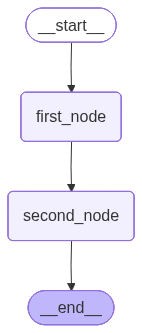

In [19]:
from IPython.display import Image , display
display(Image(app.get_graph().draw_mermaid_png()))

In [20]:
asn = app.invoke({"name":"Wal","age":40})
print(asn)

{'name': 'Wal', 'age': 40, 'final': 'Hi Wal!Your are 40 years old!'}


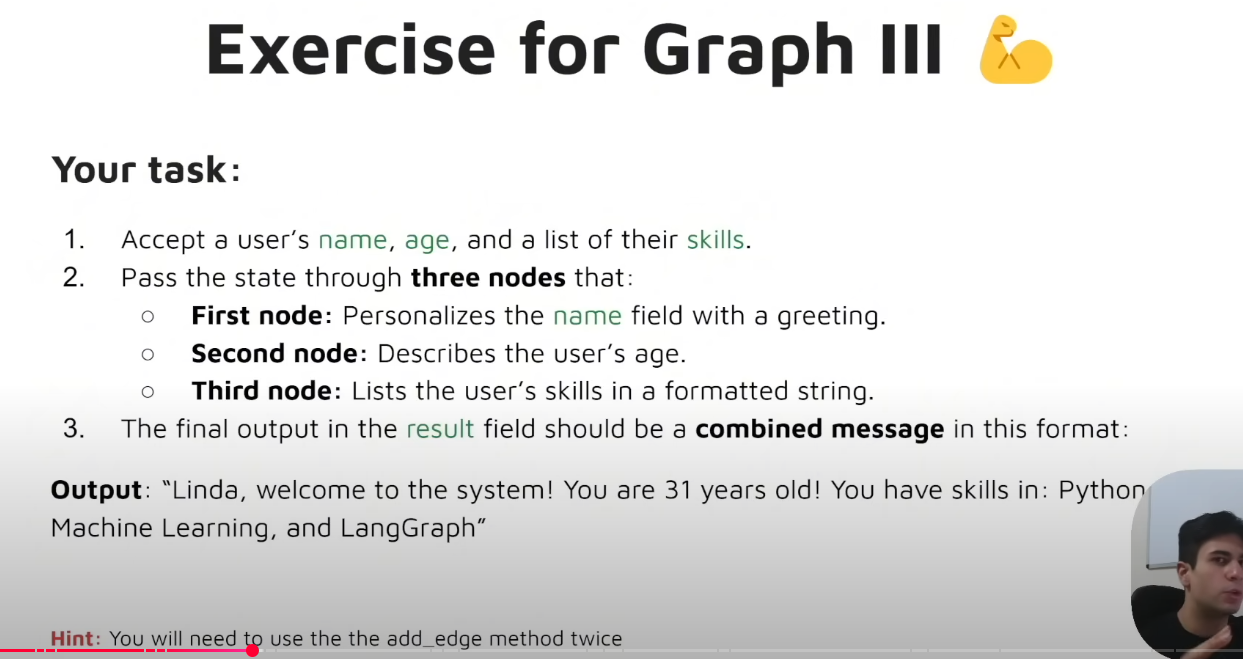